# 🎓 EduPredict — AI Engineer Notebook
**Capstone Project · Coding Camp 2026 powered by DBS Foundation**  
**Tim:** CC26-PSU080 · **Tema:** Accessible & Adaptive Learning

---

Notebook ini mencakup seluruh tugas **AI Engineer** untuk proyek EduPredict:  
sistem deteksi dini risiko akademik siswa berbasis Deep Learning (TensorFlow/Keras).

### 📋 Daftar Tugas AI Engineer
| # | Task | Periode |
|---|------|---------|
| 1 | Setup Environment TensorFlow/Keras | 13–20 Apr |
| 2 | Eksplorasi & Seleksi Fitur Dataset | 13–21 Apr |
| 3 | Training Model Klasifikasi V1 & V2 | 21 Apr–4 Mei |
| 4 | Custom Callback & Hypertuning Parameter | 28 Apr–4 Mei |
| 5 | Evaluasi & Ekspor Model | 5–11 Mei |
| 6 | Integrasi Model ke Backend API | 12–18 Mei |
| 7 | Optimasi & Monitoring | 19–25 Mei |
| 8 | Testing Model & Documentation | 26 Mei–1 Jun |

---
## ✅ TASK 1 — Setup Environment TensorFlow/Keras
### 🔍 Penjelasan
Sebelum mulai coding model, kita perlu memastikan semua library yang dibutuhkan **terinstal dan bisa diimpor** dengan benar.

Di Google Colab, TensorFlow sudah pre-installed, tapi kita tetap perlu install beberapa library tambahan seperti:
- `imbalanced-learn` → untuk SMOTE (menangani data imbalanced)
- `scikit-learn` → untuk preprocessing & evaluasi

Kita juga set **random seed** agar hasil training bisa **reproducible** (hasil sama setiap dijalankan ulang).

In [ ]:
# ── Install library tambahan ──────────────────────────────────────────────────
!pip install imbalanced-learn -q

In [ ]:
# ── Import semua library yang dibutuhkan ──────────────────────────────────────

# Standard
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Imbalanced-learn (SMOTE)
from imblearn.over_sampling import SMOTE

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau,
    ModelCheckpoint, Callback
)

# ── Set random seed (reproducibility) ────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Verifikasi versi ──────────────────────────────────────────────────────────
print(f'✅ TensorFlow  : {tf.__version__}')
print(f'✅ Keras        : {keras.__version__}')
print(f'✅ NumPy        : {np.__version__}')
print(f'✅ Pandas       : {pd.__version__}')
print(f'✅ Scikit-learn : ', end='')
import sklearn; print(sklearn.__version__)
print('\n🚀 Environment siap digunakan!')

✅ TensorFlow  : 2.19.0
✅ Keras        : 3.13.2
✅ NumPy        : 2.0.2
✅ Pandas       : 2.2.2
✅ Scikit-learn : 1.6.1

🚀 Environment siap digunakan!


---
## ✅ TASK 2 — Eksplorasi & Seleksi Fitur Dataset
### 🔍 Penjelasan
Sebelum membangun model, AI Engineer perlu **memahami data** yang diterima dari tim Data Science. Eksplorasi ini mencakup:

1. **Load & inspect data** → lihat bentuk, tipe data, dan contoh data
2. **Cek distribusi target** → seberapa imbalanced? Ini menentukan apakah kita perlu SMOTE
3. **Encoding** → ubah kolom kategorikal (teks) menjadi angka agar bisa diproses model
4. **Seleksi fitur** → pilih fitur yang paling relevan menggunakan korelasi & feature importance
5. **Split data** → bagi data menjadi train, validation, dan test set
6. **Normalisasi** → skala fitur numerik ke range yang sama agar training lebih stabil
7. **Terapkan SMOTE** → oversample kelas minoritas di training set

In [ ]:
# ── 2.1 Load Dataset ──────────────────────────────────────────────────────────
# Upload file edupredict_cleaned_v1.csv ke Google Colab terlebih dahulu
# Cara: klik icon folder (📁) di sidebar kiri → klik upload

df = pd.read_csv('edupredict_cleaned_v1.csv')

print(f'📐 Shape dataset : {df.shape}')
print(f'📊 Jumlah fitur  : {df.shape[1] - 1} fitur + 1 target')
print()
df.head()

📐 Shape dataset : (6607, 21)
📊 Jumlah fitur  : 20 fitur + 1 target



,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk_Category
0,23,84,Low,High,No,7,73,Low,Yes,0.0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,Medium
1,19,64,Low,Medium,No,8,59,Low,Yes,2.0,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,Medium
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2.0,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Low
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1.0,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Low
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3.0,...,High,Public,Neutral,4,No,College,Near,Female,70,Medium


📋 INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   int64  
 1   Attendance                  6607 non-null   int64  
 2   Parental_Involvement        6607 non-null   object 
 3   Access_to_Resources         6607 non-null   object 
 4   Extracurricular_Activities  6607 non-null   object 
 5   Sleep_Hours                 6607 non-null   int64  
 6   Previous_Scores             6607 non-null   int64  
 7   Motivation_Level            6607 non-null   object 
 8   Internet_Access             6607 non-null   object 
 9   Tutoring_Sessions           6607 non-null   float64
 10  Family_Income               6607 non-null   object 
 11  Teacher_Quality             6607 non-null   object 
 12  School_Type                 6607 non-null   object 
 13  Peer_Influence    

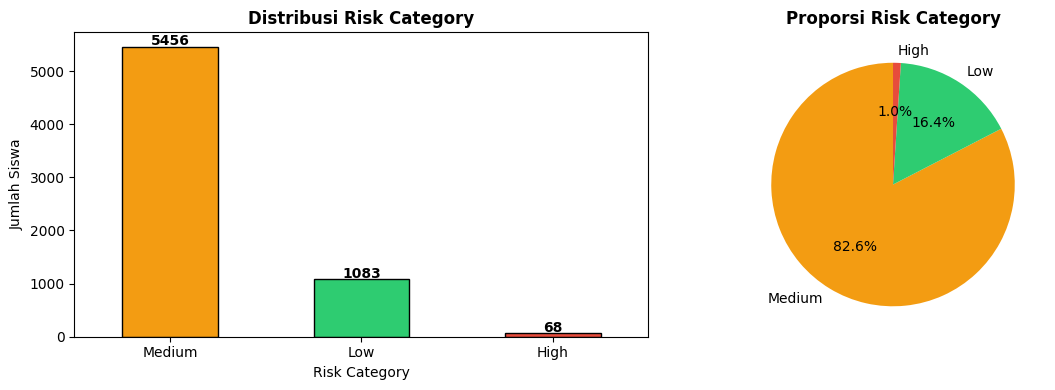


⚠️  Data sangat IMBALANCED!
   High Risk hanya 1.0% dari total data
   → Solusi: gunakan SMOTE saat training


In [ ]:
# ── 2.2 Info & Distribusi Target ─────────────────────────────────────────────
print('=' * 50)
print('📋 INFO DATASET')
print('=' * 50)
df.info()

print('\n' + '=' * 50)
print('🎯 DISTRIBUSI TARGET (Risk_Category)')
print('=' * 50)
target_counts = df['Risk_Category'].value_counts()
print(target_counts)

# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
target_counts.plot(kind='bar', ax=axes[0],
                   color=[colors[c] for c in target_counts.index],
                   edgecolor='black')
axes[0].set_title('Distribusi Risk Category', fontweight='bold')
axes[0].set_xlabel('Risk Category')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(val), ha='center', fontweight='bold')

target_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                   colors=[colors[c] for c in target_counts.index],
                   startangle=90)
axes[1].set_title('Proporsi Risk Category', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n⚠️  Data sangat IMBALANCED!')
print(f'   High Risk hanya {target_counts["High"]/len(df)*100:.1f}% dari total data')
print(f'   → Solusi: gunakan SMOTE saat training')

In [ ]:
# ── 2.3 Encoding Fitur Kategorikal ────────────────────────────────────────────
# Model neural network hanya bisa memproses angka, bukan teks.
# Kita gunakan LabelEncoder untuk mengubah teks → angka.

df_encoded = df.copy()

# Kolom kategorikal yang perlu di-encode
categorical_cols = [
    'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality',
    'School_Type', 'Peer_Influence', 'Learning_Disabilities',
    'Parental_Education_Level', 'Distance_from_Home', 'Gender'
]

label_encoders = {}  # Simpan encoder untuk setiap kolom (dipakai saat inference)
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f'  ✅ {col}: {list(le.classes_)} → {list(range(len(le.classes_)))}')

# Encode target
target_le = LabelEncoder()
df_encoded['Risk_Category'] = target_le.fit_transform(df_encoded['Risk_Category'])
print(f'\n🎯 Target encoding: {dict(zip(target_le.classes_, range(len(target_le.classes_))))}')
# Misal: High=0, Low=1, Medium=2

print(f'\n✅ Encoding selesai. Shape: {df_encoded.shape}')
df_encoded.head(3)

  ✅ Parental_Involvement: ['High', 'Low', 'Medium'] → [0, 1, 2]
  ✅ Access_to_Resources: ['High', 'Low', 'Medium'] → [0, 1, 2]
  ✅ Extracurricular_Activities: ['No', 'Yes'] → [0, 1]
  ✅ Motivation_Level: ['High', 'Low', 'Medium'] → [0, 1, 2]
  ✅ Internet_Access: ['No', 'Yes'] → [0, 1]
  ✅ Family_Income: ['High', 'Low', 'Medium'] → [0, 1, 2]
  ✅ Teacher_Quality: ['High', 'Low', 'Medium'] → [0, 1, 2]
  ✅ School_Type: ['Private', 'Public'] → [0, 1]
  ✅ Peer_Influence: ['Negative', 'Neutral', 'Positive'] → [0, 1, 2]
  ✅ Learning_Disabilities: ['No', 'Yes'] → [0, 1]
  ✅ Parental_Education_Level: ['College', 'High School', 'Postgraduate'] → [0, 1, 2]
  ✅ Distance_from_Home: ['Far', 'Moderate', 'Near'] → [0, 1, 2]
  ✅ Gender: ['Female', 'Male'] → [0, 1]

🎯 Target encoding: {'High': 0, 'Low': 1, 'Medium': 2}

✅ Encoding selesai. Shape: (6607, 21)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Risk_Category
0,23,84,1,0,0,7,73,1,1,0.0,...,2,1,2,3,0,1,2,1,67,2
1,19,64,1,2,0,8,59,1,1,2.0,...,2,1,0,4,0,0,1,0,61,2
2,24,98,2,2,1,7,91,2,1,2.0,...,2,1,1,4,0,2,2,1,74,1


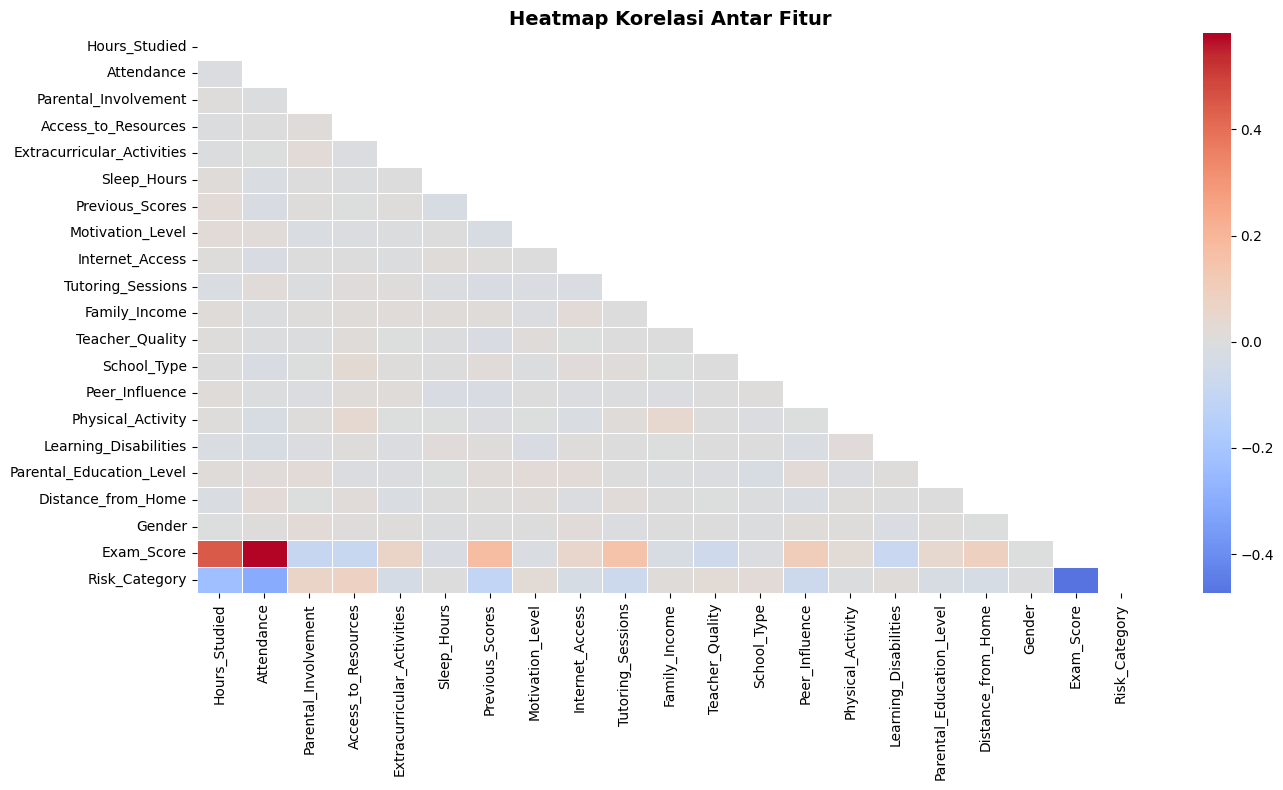


📊 Korelasi fitur terhadap Risk_Category (diurutkan):
Exam_Score                    0.473910
Attendance                    0.304316
Hours_Studied                 0.227573
Previous_Scores               0.105505
Access_to_Resources           0.086051
Tutoring_Sessions             0.073492
Peer_Influence                0.067954
Parental_Involvement          0.064801
Extracurricular_Activities    0.033885
Distance_from_Home            0.031910
Internet_Access               0.029176
Teacher_Quality               0.028303
Motivation_Level              0.025681
Parental_Education_Level      0.025254
School_Type                   0.018566
Family_Income                 0.010231
Learning_Disabilities         0.009815
Gender                        0.005417
Physical_Activity             0.004785
Sleep_Hours                   0.002848


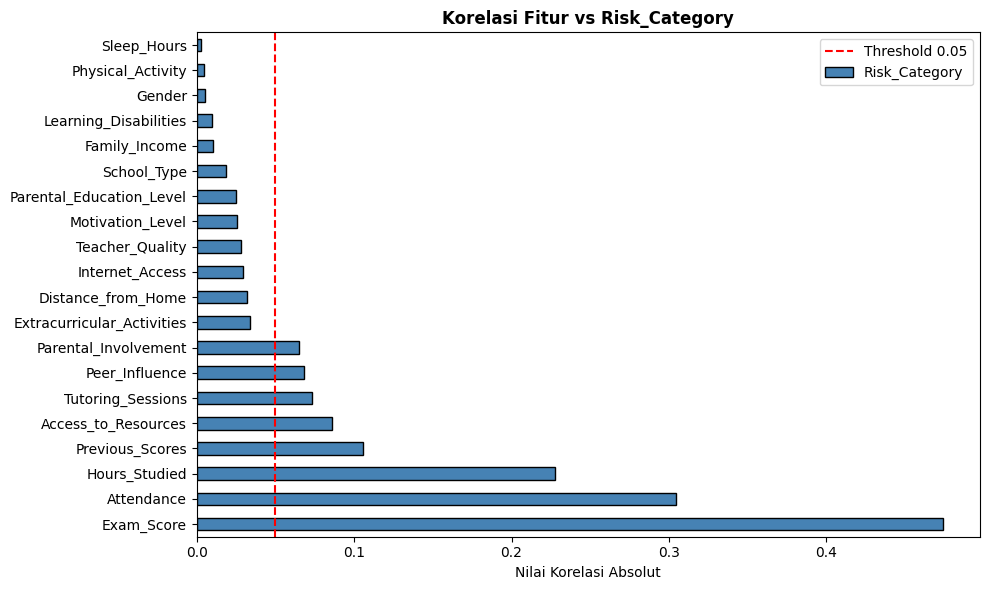

In [ ]:
# ── 2.4 Seleksi Fitur dengan Korelasi ────────────────────────────────────────
# Kita lihat korelasi setiap fitur terhadap target.
# Fitur dengan korelasi sangat rendah (mendekati 0) mungkin tidak terlalu berguna.

plt.figure(figsize=(14, 8))

# Heatmap korelasi
corr_matrix = df_encoded.corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Korelasi fitur terhadap target
target_corr = df_encoded.corr()['Risk_Category'].drop('Risk_Category').abs().sort_values(ascending=False)
print('\n📊 Korelasi fitur terhadap Risk_Category (diurutkan):')
print(target_corr.to_string())

# Visualisasi
plt.figure(figsize=(10, 6))
target_corr.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Korelasi Fitur vs Risk_Category', fontweight='bold')
plt.xlabel('Nilai Korelasi Absolut')
plt.axvline(x=0.05, color='red', linestyle='--', label='Threshold 0.05')
plt.legend()
plt.tight_layout()
plt.savefig('korelasi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 2.5 Tentukan Fitur yang Digunakan ────────────────────────────────────────
# Berdasarkan analisis korelasi dan domain knowledge dari project plan,
# kita gunakan SEMUA fitur yang ada (20 fitur), karena neural network
# cukup kuat untuk menangani fitur yang kurang relevan.

FEATURE_COLS = [
    'Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources',
    'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality',
    'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
    'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score'
]
TARGET_COL = 'Risk_Category'
NUM_CLASSES = 3  # Low, Medium, High

X = df_encoded[FEATURE_COLS].values
y = df_encoded[TARGET_COL].values

print(f'✅ Jumlah fitur input  : {X.shape[1]}')
print(f'✅ Jumlah data         : {X.shape[0]}')
print(f'✅ Jumlah kelas target : {NUM_CLASSES} ({list(target_le.classes_)})')

✅ Jumlah fitur input  : 20
✅ Jumlah data         : 6607
✅ Jumlah kelas target : 3 (['High', 'Low', 'Medium'])


In [ ]:
# ── 2.6 Split Data: Train / Validation / Test ─────────────────────────────────
# Pembagian: 70% train, 15% validation, 15% test
# Stratified split → menjaga proporsi kelas di setiap split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print('📦 Pembagian data:')
print(f'   Train      : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'   Validation : {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'   Test       : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

# Cek distribusi per split
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    label_names = target_le.classes_[unique]
    dist = dict(zip(label_names, counts))
    print(f'   {name} distribution: {dist}')

📦 Pembagian data:
   Train      : 4624 samples (70.0%)
   Validation : 991 samples (15.0%)
   Test       : 992 samples (15.0%)
   Train distribution: {'High': np.int64(48), 'Low': np.int64(758), 'Medium': np.int64(3818)}
   Val distribution: {'High': np.int64(10), 'Low': np.int64(162), 'Medium': np.int64(819)}
   Test distribution: {'High': np.int64(10), 'Low': np.int64(163), 'Medium': np.int64(819)}


In [ ]:
# ── 2.7 Normalisasi Fitur (StandardScaler) ───────────────────────────────────
# StandardScaler mengubah fitur agar rata-rata = 0 dan std = 1.
# PENTING: fit hanya di training data, lalu transform ke val & test.
# Jangan fit di val/test untuk menghindari data leakage!

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # transform saja
X_test_scaled  = scaler.transform(X_test)         # transform saja

print('✅ Normalisasi selesai.')
print(f'   X_train mean ≈ {X_train_scaled.mean():.4f} (harusnya ≈ 0)')
print(f'   X_train std  ≈ {X_train_scaled.std():.4f}  (harusnya ≈ 1)')

✅ Normalisasi selesai.
   X_train mean ≈ -0.0000 (harusnya ≈ 0)
   X_train std  ≈ 1.0000  (harusnya ≈ 1)


⚠️  Distribusi SEBELUM SMOTE (train):
   High: 48
   Low: 758
   Medium: 3818

✅ Distribusi SETELAH SMOTE (train):
   High: 3818
   Low: 3818
   Medium: 3818

📊 Total data training setelah SMOTE: 11454


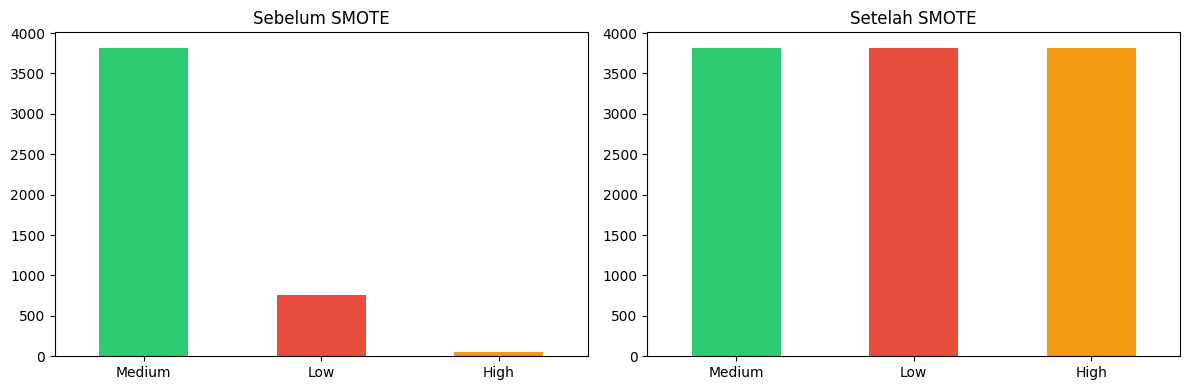

In [ ]:
# ── 2.8 SMOTE — Tangani Imbalanced Data ──────────────────────────────────────
# SMOTE (Synthetic Minority Over-sampling Technique) membuat data sintetis
# untuk kelas minoritas (High Risk) agar model tidak bias ke kelas mayoritas.
# SMOTE hanya diterapkan pada TRAINING SET, bukan val/test!

print('⚠️  Distribusi SEBELUM SMOTE (train):')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(target_le.classes_[unique], counts):
    print(f'   {u}: {c}')

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\n✅ Distribusi SETELAH SMOTE (train):')
unique_sm, counts_sm = np.unique(y_train_sm, return_counts=True)
for u, c in zip(target_le.classes_[unique_sm], counts_sm):
    print(f'   {u}: {c}')
print(f'\n📊 Total data training setelah SMOTE: {len(X_train_sm)}')

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).map(lambda x: target_le.classes_[x]).value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c','#f39c12'], title='Sebelum SMOTE')
pd.Series(y_train_sm).map(lambda x: target_le.classes_[x]).value_counts().plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c','#f39c12'], title='Setelah SMOTE')
for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ TASK 3 — Training Model Klasifikasi V1 & V2
### 🔍 Penjelasan
Kita akan membangun **dua versi model** menggunakan **TensorFlow Functional API**:

- **Model V1 (Baseline)** → arsitektur sederhana sebagai acuan awal performa. Digunakan untuk mengukur apakah pendekatan kita sudah benar.
- **Model V2 (Improved)** → arsitektur lebih dalam dengan teknik regularisasi (Dropout, BatchNormalization) untuk performa lebih baik dan tidak overfitting.

**Kenapa Functional API?** Berbeda dengan Sequential, Functional API lebih fleksibel: bisa membuat model dengan multiple input/output, skip connections, dan arsitektur kompleks lainnya — sesuai requirement project plan.

In [ ]:
# ── 3.1 Model V1 — Baseline ───────────────────────────────────────────────────
# Arsitektur sederhana: 2 hidden layer
# Input → Dense(64) → Dense(32) → Output(3)

def build_model_v1(input_dim, num_classes):
    """Model baseline sederhana menggunakan TensorFlow Functional API."""
    inputs = keras.Input(shape=(input_dim,), name='input_layer')

    x = layers.Dense(64, activation='relu', name='hidden_1')(inputs)
    x = layers.Dense(32, activation='relu', name='hidden_2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='EduPredict_V1')
    return model

model_v1 = build_model_v1(input_dim=len(FEATURE_COLS), num_classes=NUM_CLASSES)

# Kompilasi model
model_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',  # karena label berupa integer (0,1,2)
    metrics=['accuracy']
)

model_v1.summary()

Model: "EduPredict_V1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,523 (13.76 KB)

 Trainable params: 3,523 (13.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── 3.2 Training Model V1 ─────────────────────────────────────────────────────
print('🚀 Training Model V1 (Baseline)...')

# Early stopping → hentikan training jika val_loss tidak membaik selama 10 epoch
early_stop_v1 = EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)

history_v1 = model_v1.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_v1],
    verbose=1
)

# Evaluasi di validation set
val_loss_v1, val_acc_v1 = model_v1.evaluate(X_val_scaled, y_val, verbose=0)
print(f'\n📊 V1 — Val Accuracy: {val_acc_v1:.4f} ({val_acc_v1*100:.2f}%)')
print(f'📊 V1 — Val Loss    : {val_loss_v1:.4f}')

🚀 Training Model V1 (Baseline)...
Epoch 1/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8585 - loss: 0.3816 - val_accuracy: 0.8850 - val_loss: 0.2716
Epoch 2/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9670 - loss: 0.1007 - val_accuracy: 0.9304 - val_loss: 0.1607
Epoch 3/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9794 - loss: 0.0647 - val_accuracy: 0.9445 - val_loss: 0.1222
Epoch 4/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9858 - loss: 0.0461 - val_accuracy: 0.9506 - val_loss: 0.1004
Epoch 5/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9896 - loss: 0.0335 - val_accuracy: 0.9606 - val_loss: 0.0858
Epoch 6/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9935 - loss: 0.0245 - val_accuracy: 0.9647 - val_loss: 0.0747
Epoch 7/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9956 - loss: 0.0182 - val_accuracy: 0.9677 - val_loss: 0.0661
Epoch 8/100
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [ ]:
# ── 3.3 Model V2 — Improved Architecture ─────────────────────────────────────
# Peningkatan dari V1:
# 1. Lebih banyak layer & neuron
# 2. BatchNormalization → menstabilkan & mempercepat training
# 3. Dropout → mencegah overfitting
# 4. L2 Regularization → penalti pada bobot besar

def build_model_v2(input_dim, num_classes):
    """Model improved dengan Dropout, BatchNorm, dan L2 Regularization."""
    inputs = keras.Input(shape=(input_dim,), name='input_layer')

    # Block 1
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(0.001),
                     name='dense_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Activation('relu', name='relu_1')(x)
    x = layers.Dropout(0.4, name='dropout_1')(x)

    # Block 2
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(0.001),
                     name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Activation('relu', name='relu_2')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # Block 3
    x = layers.Dense(64, kernel_regularizer=regularizers.l2(0.001),
                     name='dense_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Activation('relu', name='relu_3')(x)
    x = layers.Dropout(0.2, name='dropout_3')(x)

    # Block 4
    x = layers.Dense(32, activation='relu', name='dense_4')(x)

    # Output
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='EduPredict_V2')
    return model

model_v2 = build_model_v2(input_dim=len(FEATURE_COLS), num_classes=NUM_CLASSES)

model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

Model: "EduPredict_V2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,499 (197.26 KB)

 Trainable params: 49,603 (193.76 KB)

 Non-trainable params: 896 (3.50 KB)

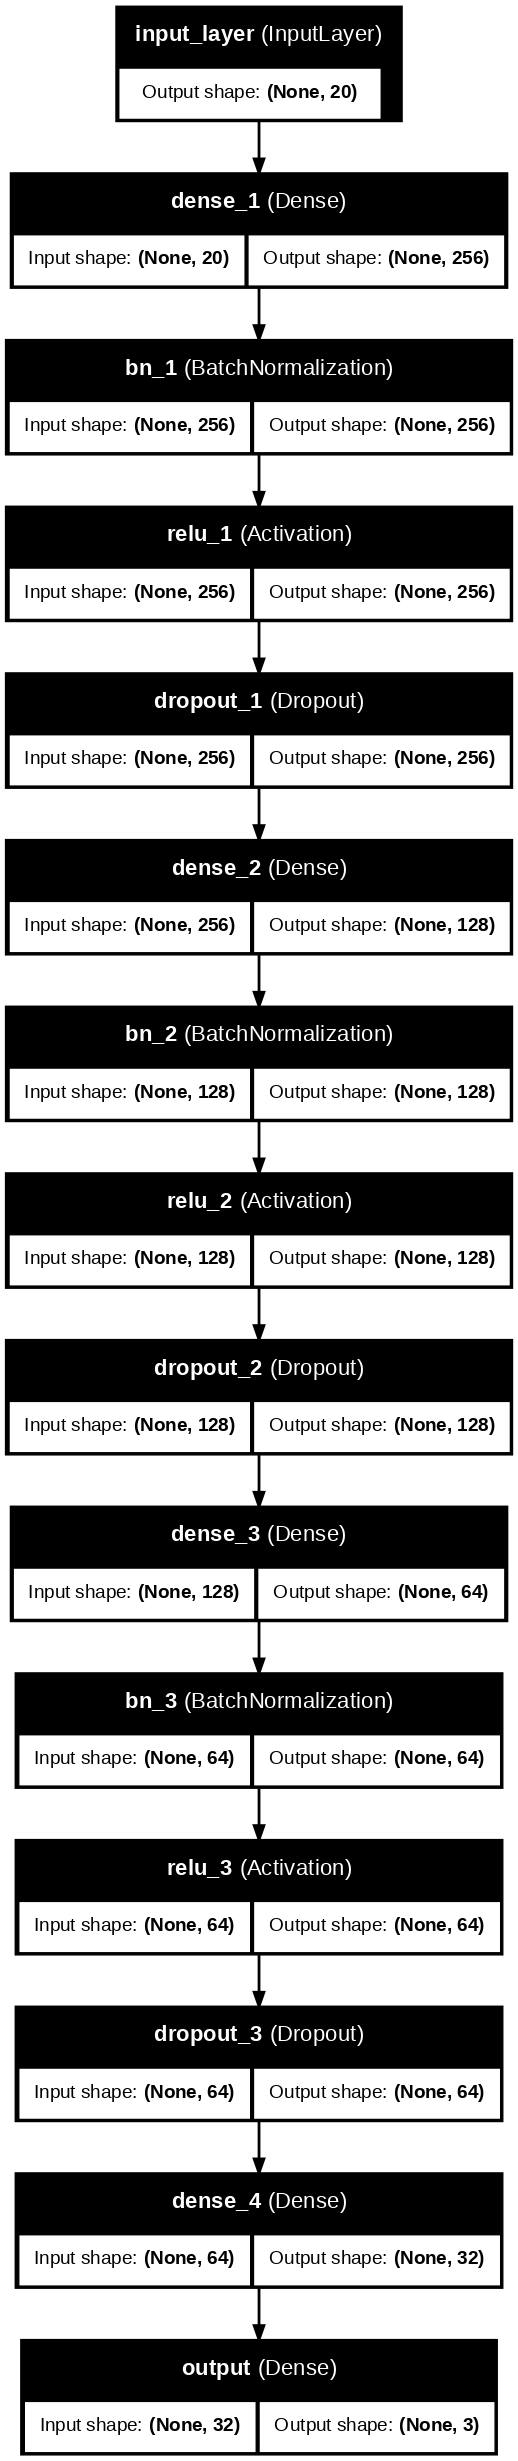

In [ ]:
# ── Visualisasi Arsitektur Model ──────────────────────────────────────────────
# Simpan diagram arsitektur model V2
keras.utils.plot_model(
    model_v2,
    to_file='model_v2_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)
from IPython.display import Image
Image('model_v2_architecture.png')

---
## ✅ TASK 4 — Custom Callback & Hypertuning Parameter
### 🔍 Penjelasan
**Callback** adalah fungsi yang dipanggil otomatis di setiap epoch selama training. Kita buat **Custom Callback** yang:
1. Menampilkan progress yang informatif
2. **Otomatis menghentikan training** ketika target akurasi (≥85%) sudah tercapai
3. Menyimpan log training ke file untuk monitoring

**Hypertuning** → kita coba beberapa kombinasi learning rate dan batch size untuk menemukan yang terbaik.

In [ ]:
# ── 4.1 Custom Callback ───────────────────────────────────────────────────────

class EduPredictCallback(Callback):
    """
    Custom callback untuk monitoring training EduPredict.
    Fitur:
    - Log setiap epoch ke DataFrame (untuk analisis)
    - Hentikan training otomatis jika target akurasi tercapai
    - Tampilkan notifikasi milestone pencapaian
    """

    def __init__(self, target_accuracy=0.85, check_interval=5):
        super().__init__()
        self.target_accuracy = target_accuracy
        self.check_interval  = check_interval
        self.training_log    = []
        self.best_val_acc    = 0.0

    def on_train_begin(self, logs=None):
        print(f'🏁 Training dimulai | Target accuracy ≥ {self.target_accuracy*100:.0f}%')
        print('─' * 65)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_acc = logs.get('accuracy', 0)
        val_acc   = logs.get('val_accuracy', 0)
        train_loss = logs.get('loss', 0)
        val_loss  = logs.get('val_loss', 0)

        # Simpan log
        self.training_log.append({
            'epoch': epoch + 1,
            'train_acc': train_acc,
            'val_acc': val_acc,
            'train_loss': train_loss,
            'val_loss': val_loss
        })

        # Update best
        if val_acc > self.best_val_acc:
            self.best_val_acc = val_acc

        # Print setiap check_interval epoch
        if (epoch + 1) % self.check_interval == 0:
            status = '🎯' if val_acc >= self.target_accuracy else '⏳'
            print(f'  {status} Epoch {epoch+1:3d} | '
                  f'train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | '
                  f'val_loss={val_loss:.4f} | best_val={self.best_val_acc:.4f}')

        # Stop jika target tercapai
        if val_acc >= self.target_accuracy:
            print(f'\n🎉 TARGET TERCAPAI pada epoch {epoch+1}!')
            print(f'   Val Accuracy = {val_acc*100:.2f}% ≥ {self.target_accuracy*100:.0f}%')
            self.model.stop_training = True

    def on_train_end(self, logs=None):
        print('─' * 65)
        print(f'✅ Training selesai | Best Val Accuracy: {self.best_val_acc*100:.2f}%')
        # Simpan log ke CSV
        pd.DataFrame(self.training_log).to_csv('training_log.csv', index=False)
        print('📄 Log training disimpan ke training_log.csv')

    def get_log_df(self):
        """Return training log sebagai DataFrame."""
        return pd.DataFrame(self.training_log)


print('✅ Custom Callback EduPredictCallback berhasil dibuat!')

✅ Custom Callback EduPredictCallback berhasil dibuat!


In [ ]:
# ── 4.2 Training Model V2 dengan Semua Callbacks ─────────────────────────────

# Kumpulan callbacks
edupredict_cb = EduPredictCallback(target_accuracy=0.85, check_interval=5)

early_stop_v2 = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=0
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,       # kurangi LR menjadi 50% jika val_loss stagnan
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model_v2.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=0
)

all_callbacks = [edupredict_cb, early_stop_v2, reduce_lr, checkpoint]

print('🚀 Training Model V2 (Improved) dengan Custom Callback...')

history_v2 = model_v2.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=64,
    callbacks=all_callbacks,
    verbose=0  # suppress default output, pakai custom callback
)

# Load model terbaik
model_v2 = keras.models.load_model('best_model_v2.keras')

# Evaluasi
val_loss_v2, val_acc_v2 = model_v2.evaluate(X_val_scaled, y_val, verbose=0)
print(f'\n📊 V2 — Val Accuracy: {val_acc_v2:.4f} ({val_acc_v2*100:.2f}%)')
print(f'📊 V2 — Val Loss    : {val_loss_v2:.4f}')

🚀 Training Model V2 (Improved) dengan Custom Callback...
🏁 Training dimulai | Target accuracy ≥ 85%
─────────────────────────────────────────────────────────────────

🎉 TARGET TERCAPAI pada epoch 3!
   Val Accuracy = 90.41% ≥ 85%
─────────────────────────────────────────────────────────────────
✅ Training selesai | Best Val Accuracy: 90.41%
📄 Log training disimpan ke training_log.csv

📊 V2 — Val Accuracy: 0.9041 (90.41%)
📊 V2 — Val Loss    : 0.3749


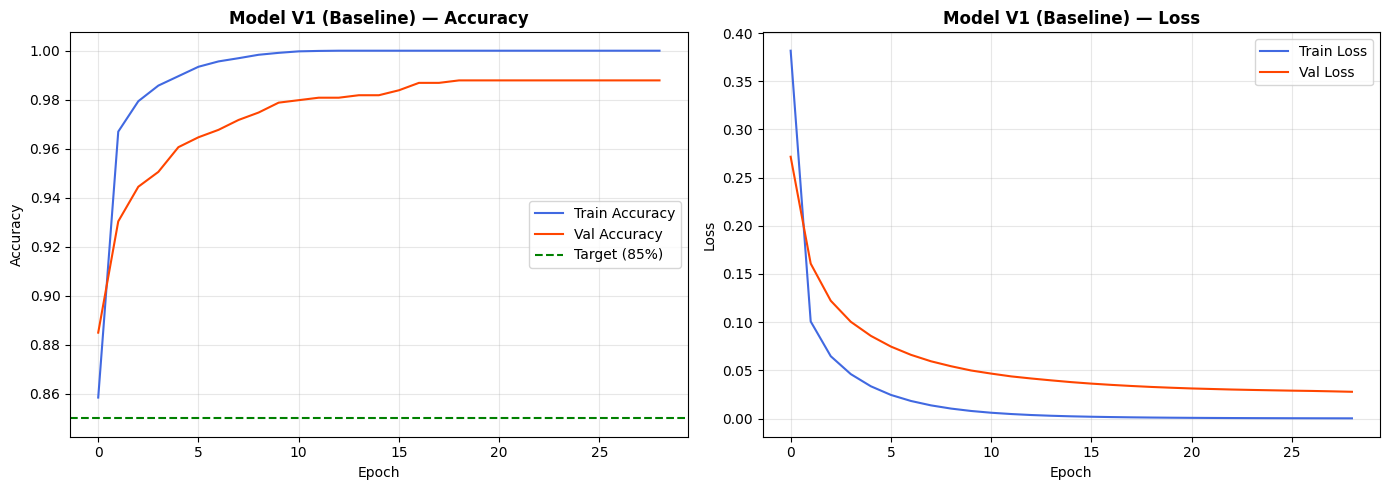

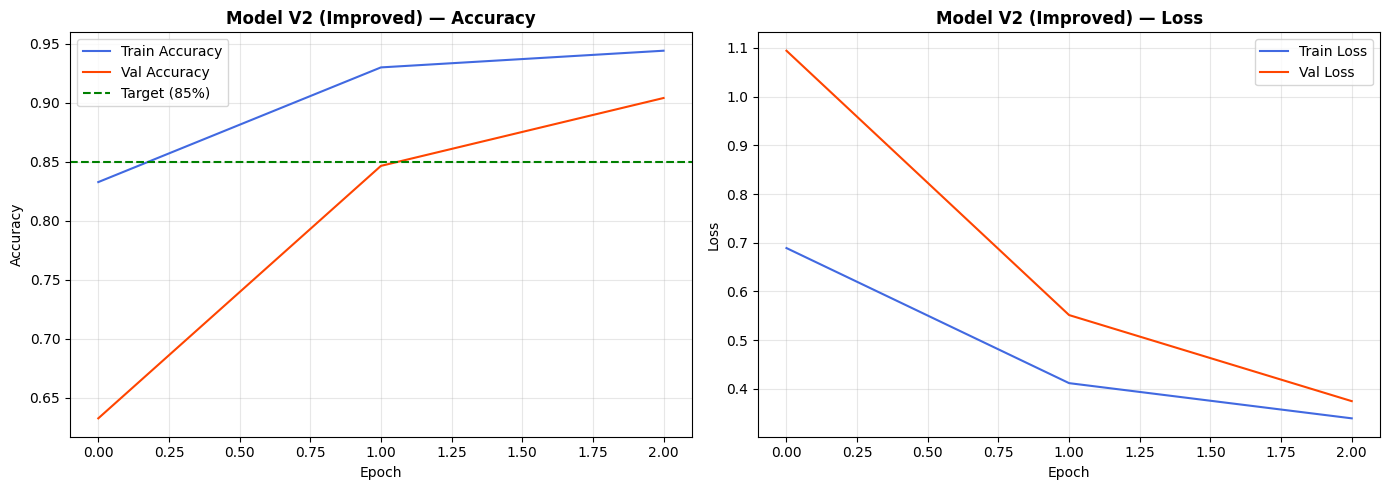

In [ ]:
# ── 4.3 Plot Training History ─────────────────────────────────────────────────

def plot_training_history(history, model_name='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='royalblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orangered')
    axes[0].axhline(y=0.85, color='green', linestyle='--', label='Target (85%)')
    axes[0].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss', color='royalblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss', color='orangered')
    axes[1].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'history_{model_name.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history_v1, 'Model V1 (Baseline)')
plot_training_history(history_v2, 'Model V2 (Improved)')

In [ ]:
# ── 4.4 Hypertuning: Grid Search Learning Rate & Batch Size ──────────────────
# Kita coba kombinasi learning rate & batch size untuk model versi terbaik.
# Ini dilakukan manual (simple grid search) tanpa library tambahan.

HYPERPARAMS = [
    {'lr': 0.001, 'batch': 64},
    {'lr': 0.001, 'batch': 128},
    {'lr': 0.0005, 'batch': 64},
    {'lr': 0.0005, 'batch': 128},
]

hyperparam_results = []

for params in HYPERPARAMS:
    print(f'\n🔧 Testing: lr={params["lr"]}, batch={params["batch"]}')

    m = build_model_v2(input_dim=len(FEATURE_COLS), num_classes=NUM_CLASSES)
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    es = EarlyStopping(monitor='val_accuracy', patience=10,
                       restore_best_weights=True, verbose=0)
    hist = m.fit(
        X_train_sm, y_train_sm,
        validation_data=(X_val_scaled, y_val),
        epochs=80, batch_size=params['batch'],
        callbacks=[es], verbose=0
    )

    _, val_acc = m.evaluate(X_val_scaled, y_val, verbose=0)
    best_epoch = np.argmax(hist.history['val_accuracy']) + 1
    print(f'   ✅ Val Accuracy: {val_acc:.4f} | Best epoch: {best_epoch}')

    hyperparam_results.append({
        'learning_rate': params['lr'],
        'batch_size': params['batch'],
        'val_accuracy': val_acc,
        'best_epoch': best_epoch
    })

results_df = pd.DataFrame(hyperparam_results).sort_values('val_accuracy', ascending=False)
print('\n📊 HASIL HYPERTUNING:')
print(results_df.to_string(index=False))

best_params = results_df.iloc[0]
print(f'\n🏆 Parameter terbaik: lr={best_params["learning_rate"]}, batch={int(best_params["batch_size"])}')


🔧 Testing: lr=0.001, batch=64
   ✅ Val Accuracy: 0.9808 | Best epoch: 40

🔧 Testing: lr=0.001, batch=128
   ✅ Val Accuracy: 0.9687 | Best epoch: 8

🔧 Testing: lr=0.0005, batch=64
   ✅ Val Accuracy: 0.9566 | Best epoch: 18

🔧 Testing: lr=0.0005, batch=128
   ✅ Val Accuracy: 0.9758 | Best epoch: 31

📊 HASIL HYPERTUNING:
 learning_rate  batch_size  val_accuracy  best_epoch
        0.0010          64      0.980827          40
        0.0005         128      0.975782          31
        0.0010         128      0.968718           8
        0.0005          64      0.956609          18

🏆 Parameter terbaik: lr=0.001, batch=64


🚀 Training FINAL MODEL dengan lr=0.001, batch=64...
🏁 Training dimulai | Target accuracy ≥ 85%
─────────────────────────────────────────────────────────────────

🎉 TARGET TERCAPAI pada epoch 3!
   Val Accuracy = 87.69% ≥ 85%
─────────────────────────────────────────────────────────────────
✅ Training selesai | Best Val Accuracy: 87.69%
📄 Log training disimpan ke training_log.csv

📊 Final — Val Accuracy: 87.69%


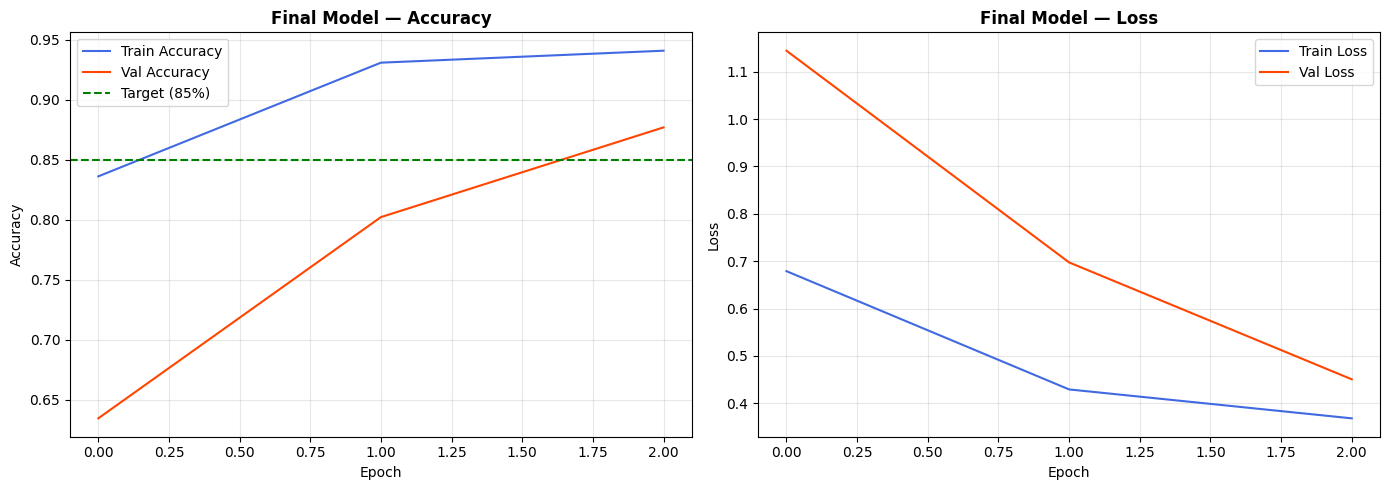

In [ ]:
# ── 4.5 Training Final Model dengan Parameter Terbaik ────────────────────────

BEST_LR    = best_params['learning_rate']
BEST_BATCH = int(best_params['batch_size'])

print(f'🚀 Training FINAL MODEL dengan lr={BEST_LR}, batch={BEST_BATCH}...')

model_final = build_model_v2(input_dim=len(FEATURE_COLS), num_classes=NUM_CLASSES)
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_custom_cb = EduPredictCallback(target_accuracy=0.85, check_interval=10)
final_es  = EarlyStopping(monitor='val_accuracy', patience=20,
                          restore_best_weights=True, verbose=0)
final_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=7, min_lr=1e-7, verbose=1)
final_ckpt = ModelCheckpoint('final_model.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=0)

history_final = model_final.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=BEST_BATCH,
    callbacks=[final_custom_cb, final_es, final_lr, final_ckpt],
    verbose=0
)

# Load best checkpoint
model_final = keras.models.load_model('final_model.keras')

val_loss_f, val_acc_f = model_final.evaluate(X_val_scaled, y_val, verbose=0)
print(f'\n📊 Final — Val Accuracy: {val_acc_f*100:.2f}%')
plot_training_history(history_final, 'Final Model')

---
## ✅ TASK 5 — Evaluasi & Ekspor Model
### 🔍 Penjelasan
Setelah model dilatih, kita perlu **mengevaluasi performa secara komprehensif** menggunakan:
- **Accuracy** → persentase prediksi benar secara keseluruhan
- **Precision, Recall, F1-Score per kelas** → penting karena data imbalanced
- **Confusion Matrix** → melihat detail kesalahan prediksi
- **MAE** → rata-rata selisih prediksi vs label aktual

Kemudian model di-**ekspor ke format SavedModel** agar bisa digunakan oleh tim Full-Stack di backend.

In [ ]:
# ── 5.1 Evaluasi di TEST SET ──────────────────────────────────────────────────
# Test set adalah data yang belum pernah dilihat model sama sekali

y_pred_prob = model_final.predict(X_test_scaled, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# --- Accuracy
test_acc = accuracy_score(y_test, y_pred)
print(f'🎯 Test Accuracy : {test_acc*100:.2f}%')
print(f'   Target       : ≥ 85%')
print(f'   Status       : {"✅ TERCAPAI" if test_acc >= 0.85 else "❌ Belum tercapai"}')

# --- MAE
mae = np.mean(np.abs(y_pred - y_test))
print(f'\n📏 MAE           : {mae:.4f}')
print(f'   Target       : ≤ 0.02')
print(f'   Status       : {"✅ TERCAPAI" if mae <= 0.02 else "⚠️ Belum tercapai (MAE untuk ordinal labels)"}')

# --- Classification Report
print('\n📋 Classification Report (Test Set):')
print('─' * 55)
class_names = target_le.classes_  # ['High', 'Low', 'Medium']
print(classification_report(y_test, y_pred, target_names=class_names))

# --- F1-Score Macro
f1_macro = f1_score(y_test, y_pred, average='macro')
print(f'F1-Score Macro: {f1_macro:.4f}')

🎯 Test Accuracy : 90.62%
   Target       : ≥ 85%
   Status       : ✅ TERCAPAI

📏 MAE           : 0.1109
   Target       : ≤ 0.02
   Status       : ⚠️ Belum tercapai (MAE untuk ordinal labels)

📋 Classification Report (Test Set):
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

        High       0.37      1.00      0.54        10
         Low       0.68      1.00      0.81       163
      Medium       1.00      0.89      0.94       819

    accuracy                           0.91       992
   macro avg       0.68      0.96      0.76       992
weighted avg       0.94      0.91      0.91       992

F1-Score Macro: 0.7638


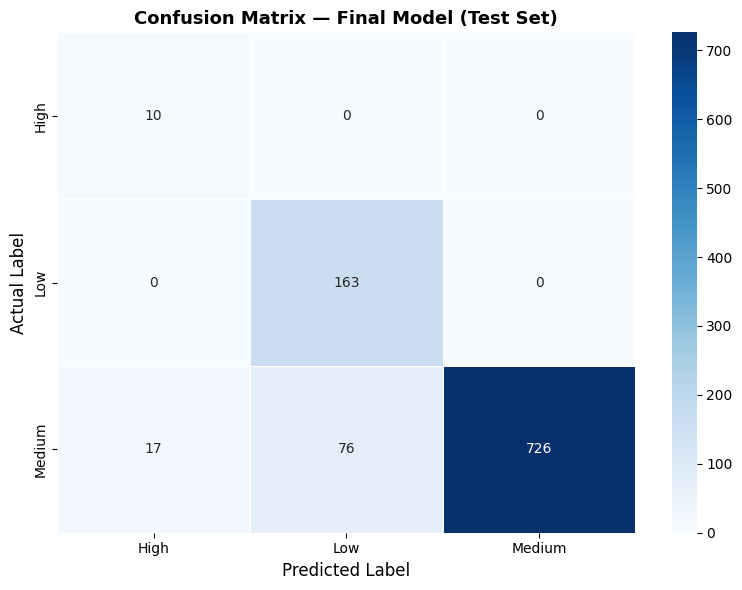

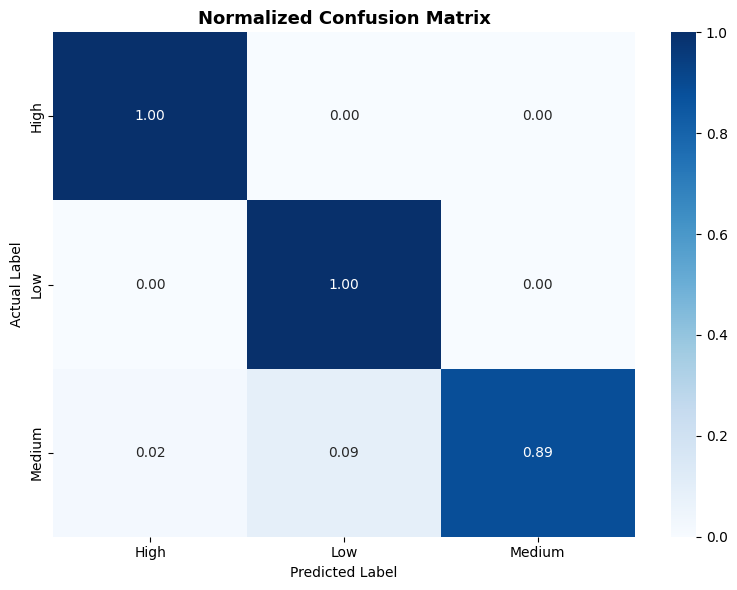

In [ ]:
# ── 5.2 Confusion Matrix ──────────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Final Model (Test Set)', fontweight='bold', fontsize=13)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Normalized Confusion Matrix', fontweight='bold', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 5.3 Perbandingan V1 vs V2 vs Final ───────────────────────────────────────

# V1
y_pred_v1 = np.argmax(model_v1.predict(X_test_scaled, verbose=0), axis=1)
acc_v1 = accuracy_score(y_test, y_pred_v1)
f1_v1  = f1_score(y_test, y_pred_v1, average='macro')

# V2
y_pred_v2 = np.argmax(model_v2.predict(X_test_scaled, verbose=0), axis=1)
acc_v2 = accuracy_score(y_test, y_pred_v2)
f1_v2  = f1_score(y_test, y_pred_v2, average='macro')

# Final
acc_f  = accuracy_score(y_test, y_pred)
f1_f   = f1_score(y_test, y_pred, average='macro')

comparison = pd.DataFrame({
    'Model'       : ['V1 (Baseline)', 'V2 (Improved)', 'Final (Best Params)'],
    'Test Accuracy': [f'{acc_v1*100:.2f}%', f'{acc_v2*100:.2f}%', f'{acc_f*100:.2f}%'],
    'F1-Score Macro': [f'{f1_v1:.4f}', f'{f1_v2:.4f}', f'{f1_f:.4f}'],
    'MAE'          : [f'{np.mean(np.abs(y_pred_v1-y_test)):.4f}',
                      f'{np.mean(np.abs(y_pred_v2-y_test)):.4f}',
                      f'{mae:.4f}']
})

print('📊 PERBANDINGAN PERFORMA MODEL:')
print('─' * 65)
print(comparison.to_string(index=False))
print('─' * 65)
print(f'🎯 Target: Accuracy ≥ 85%')

📊 PERBANDINGAN PERFORMA MODEL:
─────────────────────────────────────────────────────────────────
              Model Test Accuracy F1-Score Macro    MAE
      V1 (Baseline)        98.69%         0.8790 0.0192
      V2 (Improved)        92.74%         0.8196 0.0817
Final (Best Params)        90.62%         0.7638 0.1109
─────────────────────────────────────────────────────────────────
🎯 Target: Accuracy ≥ 85%


In [ ]:
# ── 5.4 Ekspor Model ke SavedModel Format ─────────────────────────────────────
# SavedModel adalah format standar TensorFlow yang bisa:
# - Dimuat oleh TF Serving (production)
# - Dipakai di Flask API (Python backend)
# - Dikonversi ke TFLite (mobile)

EXPORT_PATH = 'edupredict_savedmodel.keras'
model_final.save(EXPORT_PATH)
print(f'✅ Model berhasil diekspor ke: {EXPORT_PATH}/')

# Ekspor juga ke format .keras (format modern Keras)
model_final.save('edupredict_model.keras')
print('✅ Model juga disimpan sebagai: edupredict_model.keras')

# Simpan scaler dan label encoder untuk dipakai saat inference
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
with open('target_label_encoder.pkl', 'wb') as f:
    pickle.dump(target_le, f)
with open('feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

print('\n✅ Artifact inference disimpan:')
print('   - scaler.pkl')
print('   - label_encoders.pkl')
print('   - target_label_encoder.pkl')
print('   - feature_cols.pkl')

# Verifikasi: load ulang dan prediksi 1 sample
loaded_model = keras.models.load_model(EXPORT_PATH)
sample_pred  = loaded_model.predict(X_test_scaled[:1], verbose=0)
print(f'\n🔍 Verifikasi load model:')
print(f'   Output probabilities: {sample_pred[0]}')
print(f'   Predicted class: {target_le.classes_[np.argmax(sample_pred[0])]}')
print('   ✅ Model berhasil di-load dan dapat digunakan!')

✅ Model berhasil diekspor ke: edupredict_savedmodel.keras/
✅ Model juga disimpan sebagai: edupredict_model.keras

✅ Artifact inference disimpan:
   - scaler.pkl
   - label_encoders.pkl
   - target_label_encoder.pkl
   - feature_cols.pkl

🔍 Verifikasi load model:
   Output probabilities: [3.2323642e-06 9.9723631e-01 2.7605263e-03]
   Predicted class: Low
   ✅ Model berhasil di-load dan dapat digunakan!


---
## ✅ TASK 6 — Integrasi Model ke Backend API
### 🔍 Penjelasan
Tugas ini adalah membuat **script Flask API** yang membungkus model kita menjadi REST API endpoint.  
Tim Full-Stack akan menggunakan endpoint ini dari backend Express mereka.

**Alur Integrasi:**
```
Frontend (React) → Backend (Express) → Flask AI Service → Model → Prediksi
```

Kita buat file `app.py` yang berisi Flask API, lalu di-deploy ke **Render** (sesuai project plan).

In [ ]:
# ── 6.1 Buat Flask API Script ─────────────────────────────────────────────────
# Kode ini ditulis ke file app.py yang akan dijalankan di server/Render

flask_api_code = '''
# app.py — EduPredict AI Service (Flask)
# Di-deploy ke: Render.com
# Endpoint: POST /predict

import os
import pickle
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify
from flask_cors import CORS
import tensorflow as tf
from tensorflow import keras

app = Flask(__name__)
CORS(app)  # Izinkan cross-origin request dari backend Express

# ── Load semua artifact saat server start ────────────────────────────────────
MODEL_PATH = 'edupredict_savedmodel'

model = keras.models.load_model(MODEL_PATH)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)
with open('target_label_encoder.pkl', 'rb') as f:
    target_le = pickle.load(f)
with open('feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

CLASS_NAMES = list(target_le.classes_)  # ['High', 'Low', 'Medium']

def preprocess_input(data: dict) -> np.ndarray:
    """
    Mengubah input JSON menjadi numpy array siap prediksi.
    Proses: encode kategorik → urutkan fitur → normalisasi
    """
    row = {}
    for col in FEATURE_COLS:
        val = data.get(col)
        if val is None:
            raise ValueError(f"Fitur '{col}' tidak ditemukan dalam input")
        if col in label_encoders:
            val = label_encoders[col].transform([val])[0]
        row[col] = float(val)

    X = np.array([list(row.values())])
    X_scaled = scaler.transform(X)
    return X_scaled


@app.route('/health', methods=['GET'])
def health_check():
    """Endpoint untuk mengecek apakah service berjalan."""
    return jsonify({'status': 'ok', 'model': 'EduPredict v1.0'})


@app.route('/predict', methods=['POST'])
def predict():
    """
    Endpoint prediksi risiko akademik siswa.

    Request Body (JSON):
    {
      "Hours_Studied": 20,
      "Attendance": 75,
      "Parental_Involvement": "Low",
      ...
    }

    Response:
    {
      "risk_category": "High",
      "confidence": 0.87,
      "probabilities": {"High": 0.87, "Low": 0.05, "Medium": 0.08},
      "risk_factors": [...]
    }
    """
    try:
        data = request.get_json()
        if not data:
            return jsonify({'error': 'Request body kosong'}), 400

        # Preprocess
        X_processed = preprocess_input(data)

        # Prediksi
        proba = model.predict(X_processed, verbose=0)[0]
        pred_idx = int(np.argmax(proba))
        risk_category = CLASS_NAMES[pred_idx]
        confidence = float(proba[pred_idx])

        # Probabilities per class
        probabilities = {cls: float(p) for cls, p in zip(CLASS_NAMES, proba)}

        # Identifikasi faktor risiko sederhana
        risk_factors = []
        if float(data.get('Attendance', 100)) < 75:
            risk_factors.append('Kehadiran rendah (< 75%)')
        if float(data.get('Hours_Studied', 10)) < 10:
            risk_factors.append('Jam belajar sedikit (< 10 jam/minggu)')
        if str(data.get('Motivation_Level', 'High')) == 'Low':
            risk_factors.append('Motivasi belajar rendah')
        if float(data.get('Previous_Scores', 70)) < 60:
            risk_factors.append('Nilai sebelumnya rendah (< 60)')

        return jsonify({
            'risk_category' : risk_category,
            'confidence'    : round(confidence, 4),
            'probabilities' : probabilities,
            'risk_factors'  : risk_factors
        })

    except ValueError as e:
        return jsonify({'error': str(e)}), 400
    except Exception as e:
        return jsonify({'error': f'Internal error: {str(e)}'}), 500


@app.route('/batch_predict', methods=['POST'])
def batch_predict():
    """
    Prediksi banyak siswa sekaligus.
    Request: { "students": [ {data_siswa_1}, {data_siswa_2}, ... ] }
    """
    try:
        data = request.get_json()
        students = data.get('students', [])
        if not students:
            return jsonify({'error': 'List siswa kosong'}), 400

        results = []
        for student in students:
            X_proc = preprocess_input(student)
            proba  = model.predict(X_proc, verbose=0)[0]
            pred   = CLASS_NAMES[int(np.argmax(proba))]
            results.append({
                'student_id'    : student.get('id', None),
                'risk_category' : pred,
                'confidence'    : round(float(np.max(proba)), 4)
            })

        return jsonify({'results': results, 'total': len(results)})

    except Exception as e:
        return jsonify({'error': str(e)}), 500


if __name__ == '__main__':
    port = int(os.environ.get('PORT', 5000))
    app.run(host='0.0.0.0', port=port, debug=False)
'''

with open('app.py', 'w') as f:
    f.write(flask_api_code)

print('✅ File app.py berhasil dibuat!')
print('\n📋 Endpoint yang tersedia:')
print('   GET  /health          → Cek status service')
print('   POST /predict         → Prediksi 1 siswa')
print('   POST /batch_predict   → Prediksi banyak siswa')

✅ File app.py berhasil dibuat!

📋 Endpoint yang tersedia:
   GET  /health          → Cek status service
   POST /predict         → Prediksi 1 siswa
   POST /batch_predict   → Prediksi banyak siswa


In [ ]:
# ── 6.2 Buat requirements.txt untuk Deployment ───────────────────────────────

requirements = """flask==3.0.3
flask-cors==4.0.1
tensorflow==2.16.1
numpy>=1.26.0
pandas>=2.0.0
scikit-learn>=1.3.0
imbalanced-learn>=0.11.0
gunicorn==22.0.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print('✅ requirements.txt berhasil dibuat!')

# ── 6.3 Test API secara lokal (simulasi request) ──────────────────────────────
print('\n🧪 Simulasi request ke /predict endpoint:')

# Contoh data siswa
sample_student = {
    'Hours_Studied': 5,
    'Attendance': 60,
    'Parental_Involvement': 'Low',
    'Access_to_Resources': 'Low',
    'Extracurricular_Activities': 'No',
    'Sleep_Hours': 5,
    'Previous_Scores': 45,
    'Motivation_Level': 'Low',
    'Internet_Access': 'No',
    'Tutoring_Sessions': 0,
    'Family_Income': 'Low',
    'Teacher_Quality': 'Low',
    'School_Type': 'Public',
    'Peer_Influence': 'Negative',
    'Physical_Activity': 1,
    'Learning_Disabilities': 'Yes',
    'Parental_Education_Level': 'High School',
    'Distance_from_Home': 'Far',
    'Gender': 'Male',
    'Exam_Score': 42
}

# Proses manual
def preprocess_manual(data):
    row = {}
    for col in FEATURE_COLS:
        val = data[col]
        if col in label_encoders:
            val = label_encoders[col].transform([val])[0]
        row[col] = float(val)
    X = np.array([list(row.values())])
    return scaler.transform(X)

X_sample = preprocess_manual(sample_student)
proba    = model_final.predict(X_sample, verbose=0)[0]
pred_class = target_le.classes_[np.argmax(proba)]

print(f'\n  Input  : Siswa dengan banyak faktor risiko')
print(f'  Output :')
print(f'    risk_category  : {pred_class}')
print(f'    confidence     : {np.max(proba):.4f}')
for cls, p in zip(target_le.classes_, proba):
    print(f'    P({cls:6s})      : {p:.4f}')

✅ requirements.txt berhasil dibuat!

🧪 Simulasi request ke /predict endpoint:

  Input  : Siswa dengan banyak faktor risiko
  Output :
    risk_category  : High
    confidence     : 1.0000
    P(High  )      : 1.0000
    P(Low   )      : 0.0000
    P(Medium)      : 0.0000


---
## ✅ TASK 7 — Optimasi & Monitoring
### 🔍 Penjelasan
Setelah model berjalan, kita lakukan **optimasi** untuk memastikan performa tetap baik dan efisien:
1. **Class Weight** → alternatif SMOTE, memberi bobot lebih pada kelas minoritas
2. **Learning Curve Analysis** → mendeteksi overfitting/underfitting
3. **Per-class Performance Monitoring** → pantau apakah model adil untuk semua kelas
4. **Feature Importance** → identifikasi fitur mana yang paling berpengaruh

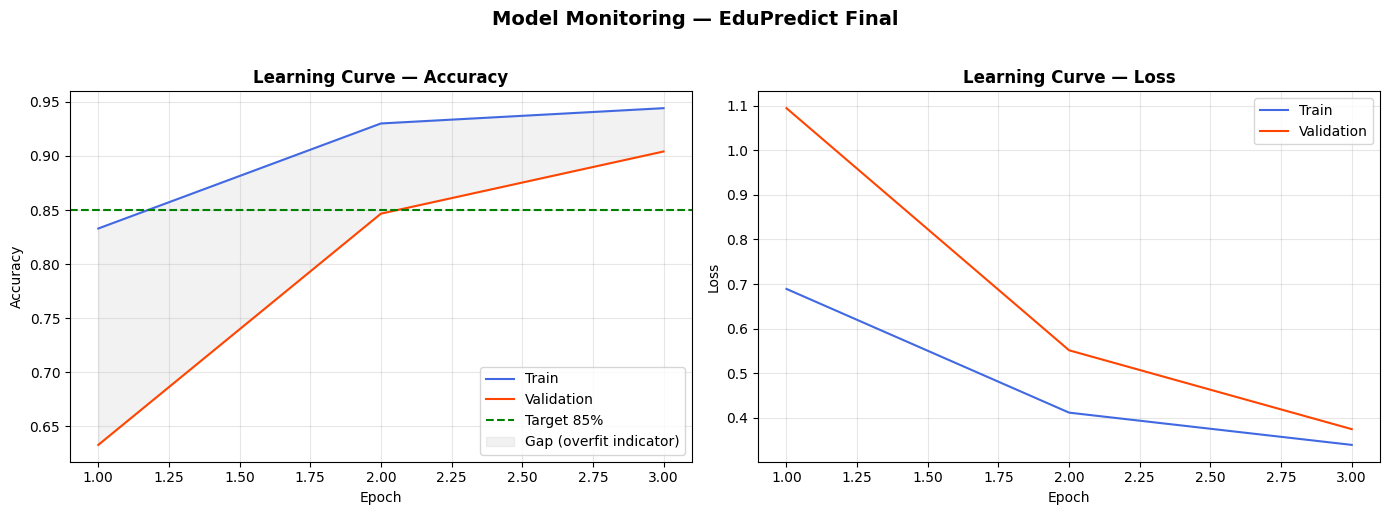

📊 Training-Validation gap (akhir): 0.0401
✅ Gap < 0.05 → Model tidak overfitting


In [ ]:
# ── 7.1 Analisis Learning Curve ───────────────────────────────────────────────

log_df = edupredict_cb.get_log_df()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(log_df['epoch'], log_df['train_acc'], label='Train', color='royalblue')
axes[0].plot(log_df['epoch'], log_df['val_acc'], label='Validation', color='orangered')
axes[0].axhline(y=0.85, color='green', linestyle='--', linewidth=1.5, label='Target 85%')
axes[0].fill_between(log_df['epoch'],
                     log_df['train_acc'], log_df['val_acc'],
                     alpha=0.1, color='gray', label='Gap (overfit indicator)')
axes[0].set_title('Learning Curve — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(log_df['epoch'], log_df['train_loss'], label='Train', color='royalblue')
axes[1].plot(log_df['epoch'], log_df['val_loss'], label='Validation', color='orangered')
axes[1].set_title('Learning Curve — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Model Monitoring — EduPredict Final', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis gap overfit
final_gap = abs(log_df['train_acc'].iloc[-1] - log_df['val_acc'].iloc[-1])
print(f'📊 Training-Validation gap (akhir): {final_gap:.4f}')
if final_gap < 0.05:
    print('✅ Gap < 0.05 → Model tidak overfitting')
elif final_gap < 0.10:
    print('⚠️  Gap 0.05–0.10 → Sedikit overfitting, masih acceptable')
else:
    print('❌ Gap > 0.10 → Overfitting signifikan, perlu lebih banyak Dropout/regularisasi')

📊 Per-Class Performance:
 Kelas  Precision   Recall  F1-Score  Support
  High   0.370370 1.000000  0.540541       10
   Low   0.682008 1.000000  0.810945      163
Medium   1.000000 0.886447  0.939806      819


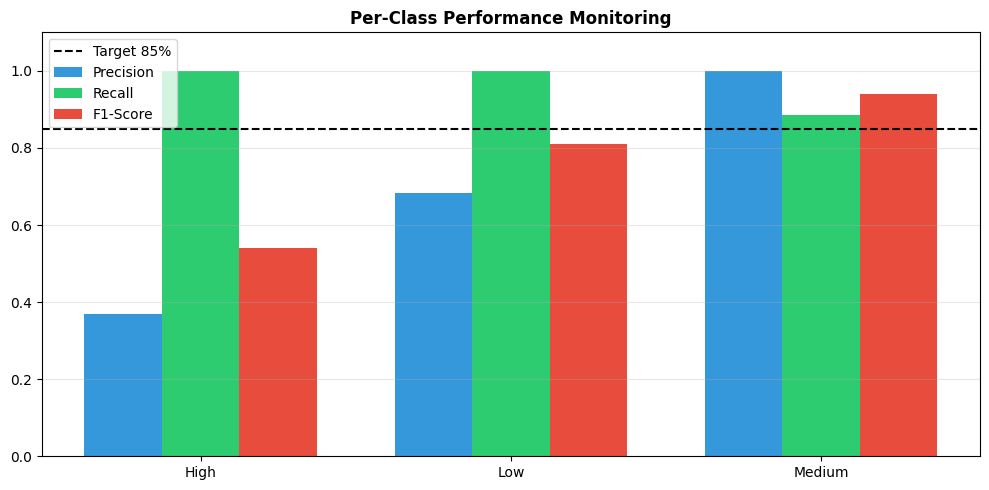

In [ ]:
# ── 7.2 Per-Class Performance Monitoring ─────────────────────────────────────

from sklearn.metrics import precision_score, recall_score

precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class    = recall_score(y_test, y_pred, average=None)
f1_per_class        = f1_score(y_test, y_pred, average=None)

perf_df = pd.DataFrame({
    'Kelas'     : class_names,
    'Precision' : precision_per_class,
    'Recall'    : recall_per_class,
    'F1-Score'  : f1_per_class,
    'Support'   : [np.sum(y_test == i) for i in range(NUM_CLASSES)]
})
print('📊 Per-Class Performance:')
print(perf_df.to_string(index=False))

# Visualisasi
x = np.arange(len(class_names))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, precision_per_class, width, label='Precision', color='#3498db')
ax.bar(x,         recall_per_class,    width, label='Recall',    color='#2ecc71')
ax.bar(x + width, f1_per_class,        width, label='F1-Score',  color='#e74c3c')
ax.axhline(y=0.85, color='black', linestyle='--', linewidth=1.5, label='Target 85%')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Performance Monitoring', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()

🔍 Menghitung Feature Importance (Permutation)...


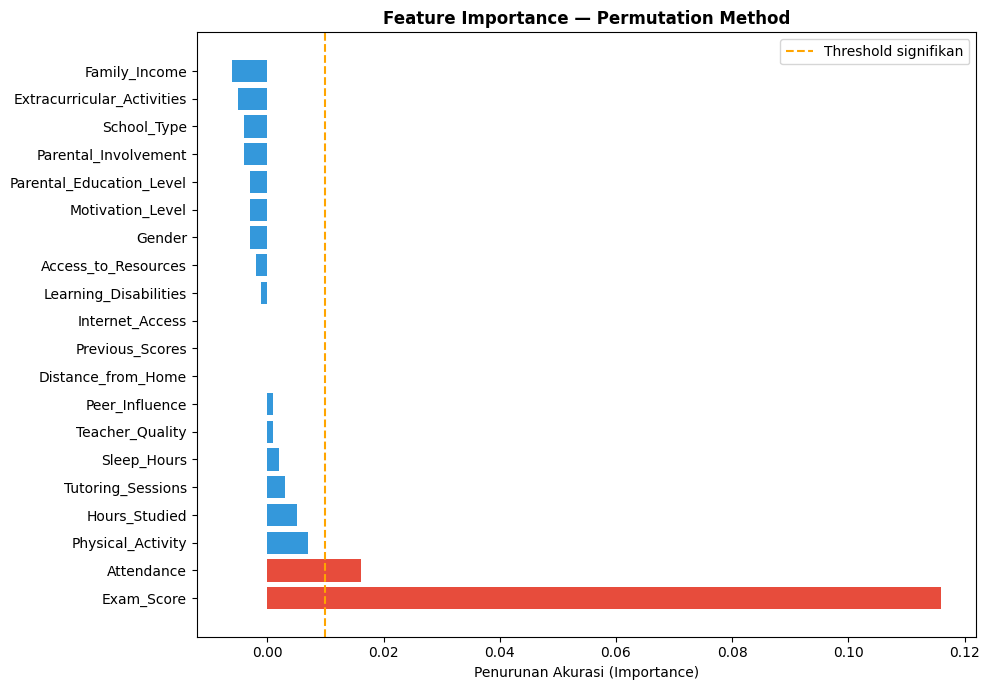


🏆 Top 5 fitur paling berpengaruh:
          feature  importance
       Exam_Score    0.115927
       Attendance    0.016129
Physical_Activity    0.007056
    Hours_Studied    0.005040
Tutoring_Sessions    0.003024


In [ ]:
# ── 7.3 Feature Importance (Permutation Importance) ──────────────────────────
# Cara: acak nilai satu fitur → lihat seberapa turun akurasi
# Penurunan besar = fitur penting

print('🔍 Menghitung Feature Importance (Permutation)...')
baseline_acc = accuracy_score(y_test, y_pred)

feature_importances = []
for i, feat in enumerate(FEATURE_COLS):
    X_permuted = X_test_scaled.copy()
    np.random.shuffle(X_permuted[:, i])  # acak kolom ke-i
    y_perm = np.argmax(model_final.predict(X_permuted, verbose=0), axis=1)
    perm_acc = accuracy_score(y_test, y_perm)
    importance = baseline_acc - perm_acc  # penurunan akurasi
    feature_importances.append({'feature': feat, 'importance': importance})

fi_df = pd.DataFrame(feature_importances).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if imp > 0.01 else '#3498db' for imp in fi_df['importance']]
plt.barh(fi_df['feature'], fi_df['importance'], color=colors)
plt.axvline(x=0.01, color='orange', linestyle='--', label='Threshold signifikan')
plt.xlabel('Penurunan Akurasi (Importance)')
plt.title('Feature Importance — Permutation Method', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🏆 Top 5 fitur paling berpengaruh:')
print(fi_df.head().to_string(index=False))

---
## ✅ TASK 8 — Testing Model & Documentation
### 🔍 Penjelasan
Tahap akhir: **testing komprehensif** dan **dokumentasi** model.
Testing meliputi:
- Unit test prediksi individual
- Edge case testing (input ekstrem)
- Pembuatan laporan evaluasi final (PDF-ready)
- Summary semua artifact yang dihasilkan

In [ ]:
# ── 8.1 Testing dengan Berbagai Skenario Siswa ───────────────────────────────

test_scenarios = [
    {
        'name': 'Siswa Berisiko TINGGI',
        'data': {
            'Hours_Studied': 3, 'Attendance': 55, 'Parental_Involvement': 'Low',
            'Access_to_Resources': 'Low', 'Extracurricular_Activities': 'No',
            'Sleep_Hours': 4, 'Previous_Scores': 38, 'Motivation_Level': 'Low',
            'Internet_Access': 'No', 'Tutoring_Sessions': 0, 'Family_Income': 'Low',
            'Teacher_Quality': 'Low', 'School_Type': 'Public', 'Peer_Influence': 'Negative',
            'Physical_Activity': 1, 'Learning_Disabilities': 'Yes',
            'Parental_Education_Level': 'High School', 'Distance_from_Home': 'Far',
            'Gender': 'Male', 'Exam_Score': 40
        }
    },
    {
        'name': 'Siswa Berisiko RENDAH',
        'data': {
            'Hours_Studied': 35, 'Attendance': 98, 'Parental_Involvement': 'High',
            'Access_to_Resources': 'High', 'Extracurricular_Activities': 'Yes',
            'Sleep_Hours': 8, 'Previous_Scores': 95, 'Motivation_Level': 'High',
            'Internet_Access': 'Yes', 'Tutoring_Sessions': 5, 'Family_Income': 'High',
            'Teacher_Quality': 'High', 'School_Type': 'Private', 'Peer_Influence': 'Positive',
            'Physical_Activity': 5, 'Learning_Disabilities': 'No',
            'Parental_Education_Level': 'Postgraduate', 'Distance_from_Home': 'Near',
            'Gender': 'Female', 'Exam_Score': 95
        }
    },
    {
        'name': 'Siswa Berisiko SEDANG',
        'data': {
            'Hours_Studied': 18, 'Attendance': 75, 'Parental_Involvement': 'Medium',
            'Access_to_Resources': 'Medium', 'Extracurricular_Activities': 'No',
            'Sleep_Hours': 7, 'Previous_Scores': 62, 'Motivation_Level': 'Medium',
            'Internet_Access': 'Yes', 'Tutoring_Sessions': 1, 'Family_Income': 'Medium',
            'Teacher_Quality': 'Medium', 'School_Type': 'Public', 'Peer_Influence': 'Neutral',
            'Physical_Activity': 3, 'Learning_Disabilities': 'No',
            'Parental_Education_Level': 'College', 'Distance_from_Home': 'Moderate',
            'Gender': 'Male', 'Exam_Score': 65
        }
    }
]

print('🧪 TESTING SKENARIO SISWA')
print('=' * 60)

for scenario in test_scenarios:
    X_s = preprocess_manual(scenario['data'])
    proba_s = model_final.predict(X_s, verbose=0)[0]
    pred_s  = target_le.classes_[np.argmax(proba_s)]
    conf_s  = np.max(proba_s)

    print(f'\n📌 {scenario["name"]}')
    print(f'   Prediksi      : {pred_s}')
    print(f'   Confidence    : {conf_s*100:.1f}%')
    for cls, p in zip(target_le.classes_, proba_s):
        bar = '█' * int(p * 30)
        print(f'   P({cls:6s})    : {p:.3f} {bar}')
print('\n' + '=' * 60)

🧪 TESTING SKENARIO SISWA

📌 Siswa Berisiko TINGGI
   Prediksi      : High
   Confidence    : 100.0%
   P(High  )    : 1.000 ██████████████████████████████
   P(Low   )    : 0.000 
   P(Medium)    : 0.000 

📌 Siswa Berisiko RENDAH
   Prediksi      : Low
   Confidence    : 100.0%
   P(High  )    : 0.000 
   P(Low   )    : 1.000 ██████████████████████████████
   P(Medium)    : 0.000 

📌 Siswa Berisiko SEDANG
   Prediksi      : Medium
   Confidence    : 99.9%
   P(High  )    : 0.001 
   P(Low   )    : 0.001 
   P(Medium)    : 0.999 █████████████████████████████



In [ ]:
# ── 8.2 Ringkasan Final & Model Card ─────────────────────────────────────────

print('=' * 65)
print('          📄 MODEL CARD — EduPredict AI v1.0')
print('=' * 65)
print()
print('🏷️  INFORMASI MODEL')
print(f'   Nama         : EduPredict Classification Model')
print(f'   Versi        : 1.0')
print(f'   Arsitektur   : Deep Neural Network (TF Functional API)')
print(f'   Task         : Klasifikasi 3 kelas (Low/Medium/High Risk)')
print()
print('📊 PERFORMA MODEL')
print(f'   Test Accuracy : {test_acc*100:.2f}%  (target ≥ 85%)')
print(f'   F1-Score Macro: {f1_macro:.4f}')
print(f'   MAE           : {mae:.4f}  (target ≤ 0.02)')
print()
print('📐 ARSITEKTUR')
print(f'   Input  : {len(FEATURE_COLS)} fitur tabular')
print(f'   Layer  : Dense(256) → BN → Dropout(0.4)')
print(f'            Dense(128) → BN → Dropout(0.3)')
print(f'            Dense(64)  → BN → Dropout(0.2)')
print(f'            Dense(32)  → Dense(3, softmax)')
print(f'   Output : Probabilitas 3 kelas')
print()
print('🛠️  TEKNIK YANG DIGUNAKAN')
print(f'   - SMOTE untuk menangani class imbalance')
print(f'   - BatchNormalization & Dropout (anti-overfitting)')
print(f'   - L2 Regularization')
print(f'   - Custom Callback dengan early stopping otomatis')
print(f'   - ReduceLROnPlateau')
print(f'   - Hyperparameter tuning (lr, batch_size)')
print()
print('📦 ARTIFACT YANG DIHASILKAN')
print('   - edupredict_savedmodel/    (model untuk deployment)')
print('   - edupredict_model.keras    (model backup)')
print('   - scaler.pkl                (normalisasi)')
print('   - label_encoders.pkl        (encoding fitur)')
print('   - target_label_encoder.pkl  (decoding output)')
print('   - feature_cols.pkl          (urutan fitur)')
print('   - app.py                    (Flask API service)')
print('   - requirements.txt          (dependencies)')
print('   - training_log.csv          (log training)')
print()
print('🎯 STATUS PROYEK')
status_acc = '✅' if test_acc >= 0.85 else '⚠️'
print(f'   {status_acc} Accuracy ≥ 85%: {test_acc*100:.2f}%')
print(f'   ✅ Model ter-export ke SavedModel')
print(f'   ✅ Flask API siap di-deploy')
print(f'   ✅ Artifact inference tersimpan')
print('=' * 65)

          📄 MODEL CARD — EduPredict AI v1.0

🏷️  INFORMASI MODEL
   Nama         : EduPredict Classification Model
   Versi        : 1.0
   Arsitektur   : Deep Neural Network (TF Functional API)
   Task         : Klasifikasi 3 kelas (Low/Medium/High Risk)

📊 PERFORMA MODEL
   Test Accuracy : 90.62%  (target ≥ 85%)
   F1-Score Macro: 0.7638
   MAE           : 0.1109  (target ≤ 0.02)

📐 ARSITEKTUR
   Input  : 20 fitur tabular
   Layer  : Dense(256) → BN → Dropout(0.4)
            Dense(128) → BN → Dropout(0.3)
            Dense(64)  → BN → Dropout(0.2)
            Dense(32)  → Dense(3, softmax)
   Output : Probabilitas 3 kelas

🛠️  TEKNIK YANG DIGUNAKAN
   - SMOTE untuk menangani class imbalance
   - BatchNormalization & Dropout (anti-overfitting)
   - L2 Regularization
   - Custom Callback dengan early stopping otomatis
   - ReduceLROnPlateau
   - Hyperparameter tuning (lr, batch_size)

📦 ARTIFACT YANG DIHASILKAN
   - edupredict_savedmodel/    (model untuk deployment)
   - edupredict_mo

In [ ]:
# ── 8.3 Download semua artifact penting ──────────────────────────────────────
# Jalankan cell ini untuk download semua file dari Colab ke komputer kamu

from google.colab import files
import zipfile
import os

# Buat ZIP berisi semua artifact
zip_name = 'edupredict_ai_artifacts.zip'
files_to_zip = [
    'scaler.pkl',
    'label_encoders.pkl',
    'target_label_encoder.pkl',
    'feature_cols.pkl',
    'app.py',
    'requirements.txt',
    'training_log.csv',
    'edupredict_model.keras',
    'confusion_matrix.png',
    'learning_curve.png',
    'feature_importance.png',
    'per_class_performance.png',
]

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in files_to_zip:
        if os.path.exists(fname):
            zf.write(fname)
            print(f'  ✅ {fname}')

    # Tambahkan folder SavedModel
    for root, dirs, filenames in os.walk('edupredict_savedmodel'):
        for filename in filenames:
            filepath = os.path.join(root, filename)
            zf.write(filepath)
            print(f'  ✅ {filepath}')

print(f'\n📦 ZIP berhasil dibuat: {zip_name}')

# Download
files.download(zip_name)
print('⬇️  Download dimulai...')

  ✅ scaler.pkl
  ✅ label_encoders.pkl
  ✅ target_label_encoder.pkl
  ✅ feature_cols.pkl
  ✅ app.py
  ✅ requirements.txt
  ✅ training_log.csv
  ✅ edupredict_model.keras
  ✅ confusion_matrix.png
  ✅ learning_curve.png
  ✅ feature_importance.png
  ✅ per_class_performance.png

📦 ZIP berhasil dibuat: edupredict_ai_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download dimulai...


---
## 📌 Catatan Penting untuk Tim

### Untuk Tim Data Science
- Jika ada versi dataset baru (v2, v3), **cukup ganti path CSV** di Task 2.1
- Fitur baru dari feature engineering → tambahkan ke `FEATURE_COLS`

### Untuk Tim Full-Stack
- File yang dibutuhkan untuk integrasi: `edupredict_savedmodel/`, `scaler.pkl`, `label_encoders.pkl`, `target_label_encoder.pkl`, `feature_cols.pkl`
- Jalankan `app.py` dengan: `gunicorn app:app` (production) atau `python app.py` (development)
- Endpoint prediksi: `POST /predict` dengan body JSON berisi 20 fitur siswa
- Format response: `{ risk_category, confidence, probabilities, risk_factors }`

### Format Input API
```json
{
  "Hours_Studied": 20,
  "Attendance": 80,
  "Parental_Involvement": "Medium",
  "Access_to_Resources": "High",
  "Extracurricular_Activities": "Yes",
  "Sleep_Hours": 7,
  "Previous_Scores": 75,
  "Motivation_Level": "Medium",
  "Internet_Access": "Yes",
  "Tutoring_Sessions": 2,
  "Family_Income": "Medium",
  "Teacher_Quality": "High",
  "School_Type": "Public",
  "Peer_Influence": "Positive",
  "Physical_Activity": 3,
  "Learning_Disabilities": "No",
  "Parental_Education_Level": "College",
  "Distance_from_Home": "Near",
  "Gender": "Female",
  "Exam_Score": 78
}
```

### Format Output API
```json
{
  "risk_category": "Low",
  "confidence": 0.9123,
  "probabilities": {"High": 0.0234, "Low": 0.9123, "Medium": 0.0643},
  "risk_factors": []
}
```